In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os
import sys

In [2]:
# Load the raw npz file
raw_data = np.load('simulation_data.npz')
y_vals = raw_data['y_vals']
u_plot = raw_data['u_plot']

# Assuming y_vals contains [Cart 1 Pos, Cart 1 Vel, Cart 2 Pos, Cart 2 Vel]
columns = ['Input Force (u)', 'Cart 1 Pos (x1)', 'Cart 1 Vel (x1_dot)', 'Cart 2 Pos (x2)', 'Cart 2 Vel (x2_dot)']

# Create a DataFrame combining both raw arrays
# We use np.column_stack to attach the 1D u_plot alongside the 2D y_vals
df = pd.DataFrame(
    np.column_stack((u_plot, y_vals)),
    columns=columns
)

# Set the index name to represent Time Steps
df.index.name = 'Time Step'
display(df.head(10))


,Input Force (u),Cart 1 Pos (x1),Cart 1 Vel (x1_dot),Cart 2 Pos (x2),Cart 2 Vel (x2_dot)
Time Step,,,,,
0,0.993428,0.000000,0.000000,0.000000e+00,0.000000
1,0.993428,0.000197,0.039277,6.578013e-07,0.000197
2,0.993428,0.000783,0.077646,5.227087e-06,0.000781
3,0.993428,0.001747,0.115126,1.752287e-05,0.001740
4,0.993428,0.003082,0.151736,4.125689e-05,0.003066
5,0.993428,0.004779,0.187495,8.003968e-05,0.004749
6,0.993428,0.006829,0.222419,1.373827e-04,0.006777
7,0.993428,0.009225,0.256528,2.167003e-04,0.009142
8,0.993428,0.011957,0.289837,3.213117e-04,0.011834


In [3]:
# normalize the data 
y_mean, y_std = y_vals.mean(axis=0), y_vals.std(axis=0)
u_mean, u_std = u_plot.mean(), u_plot.std()

y_norm = (y_vals - y_mean) / (y_std + 1e-8)
u_norm = (u_plot - u_mean) / (u_std + 1e-8)

# convert to torch tensors
Y = torch.tensor(y_norm, dtype=torch.float32)
U = torch.tensor(u_norm, dtype=torch.float32).unsqueeze(1)

print(f"Data is normalized. Final shapes ready for model:")
print(f"Y Shape: {Y.shape} | U Shape: {U.shape}")

Data is normalized. Final shapes ready for model:
Y Shape: torch.Size([20000, 4]) | U Shape: torch.Size([20000, 1])


# Changed tanh to relu

Now the model doesnt simply just squash $h_k$ to -1 and 1 anymore after switching to relu. Instead, it now sets all $h_k$ to 0 if < 0 or else keeps it. 

In [5]:
# define the model
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        
        # Memory Update Weights
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
        self.W_uh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        
        # State Prediction Weights
        self.W_hx = nn.Parameter(torch.randn(hidden_size, output_size) * 0.1)
        self.b_x = nn.Parameter(torch.zeros(output_size))
    
    def forward(self, u_seq):
        # get sequence length
        seq_len = u_seq.shape[0]

        # initialize hidden state
        h_k = torch.zeros(self.hidden_size, device=u_seq.device)

        # initialize list to store predictions
        y_pred = []

        # loop through the sequence
        for k in range(seq_len):
            # get current input
            u_k = u_seq[k]

            # update hidden state
            h_k = torch.relu(h_k @ self.W_hh + u_k @ self.W_uh + self.b_h)

            # predict next state
            y_k = h_k @ self.W_hx + self.b_x

            # store prediction
            y_pred.append(y_k)

        # convert list to tensor
        y_pred = torch.stack(y_pred)

        return y_pred

# Training with `hidden_size=4` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=1, hidden_size=4, output_size=4).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 100
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len)
        end_idx = start_idx + seq_len
        
        # Get the chunks of data using slicing [start_idx:end_idx]
        U_chunk = U[start_idx:end_idx].to(device)
        Y_chunk = Y[start_idx:end_idx].to(device)
        
        # Forward pass
        Y_pred_chunk = model(U_chunk)
        
        # Calculate Loss
        loss = criterion(Y_pred_chunk, Y_chunk)
        
        # Backpropagate and Update
        loss.backward()

        batch_loss += loss.item()
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # Print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/100, Average Batch Loss: 0.6626
Epoch 20/100, Average Batch Loss: 1.2238
Epoch 30/100, Average Batch Loss: 0.9470
Epoch 40/100, Average Batch Loss: 1.2640
Epoch 50/100, Average Batch Loss: 0.6696
Epoch 60/100, Average Batch Loss: 1.0088
Epoch 70/100, Average Batch Loss: 1.1711
Epoch 80/100, Average Batch Loss: 0.6728
Epoch 90/100, Average Batch Loss: 1.0640
Epoch 100/100, Average Batch Loss: 1.0959


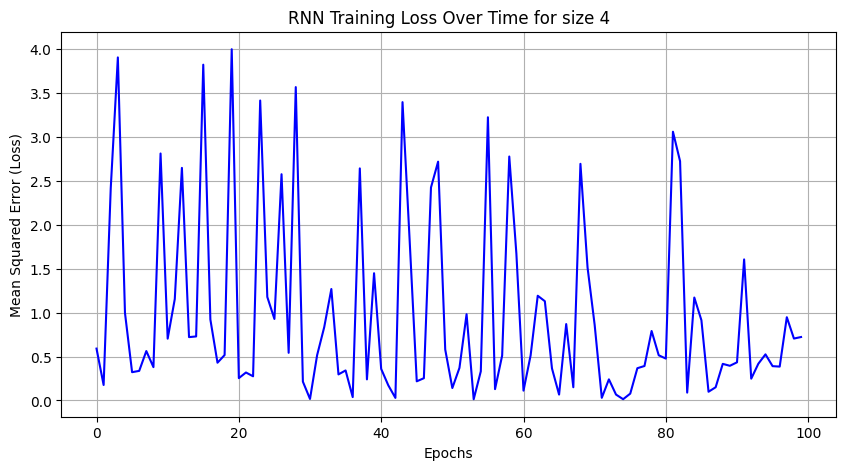

In [42]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 4')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN for size 4 


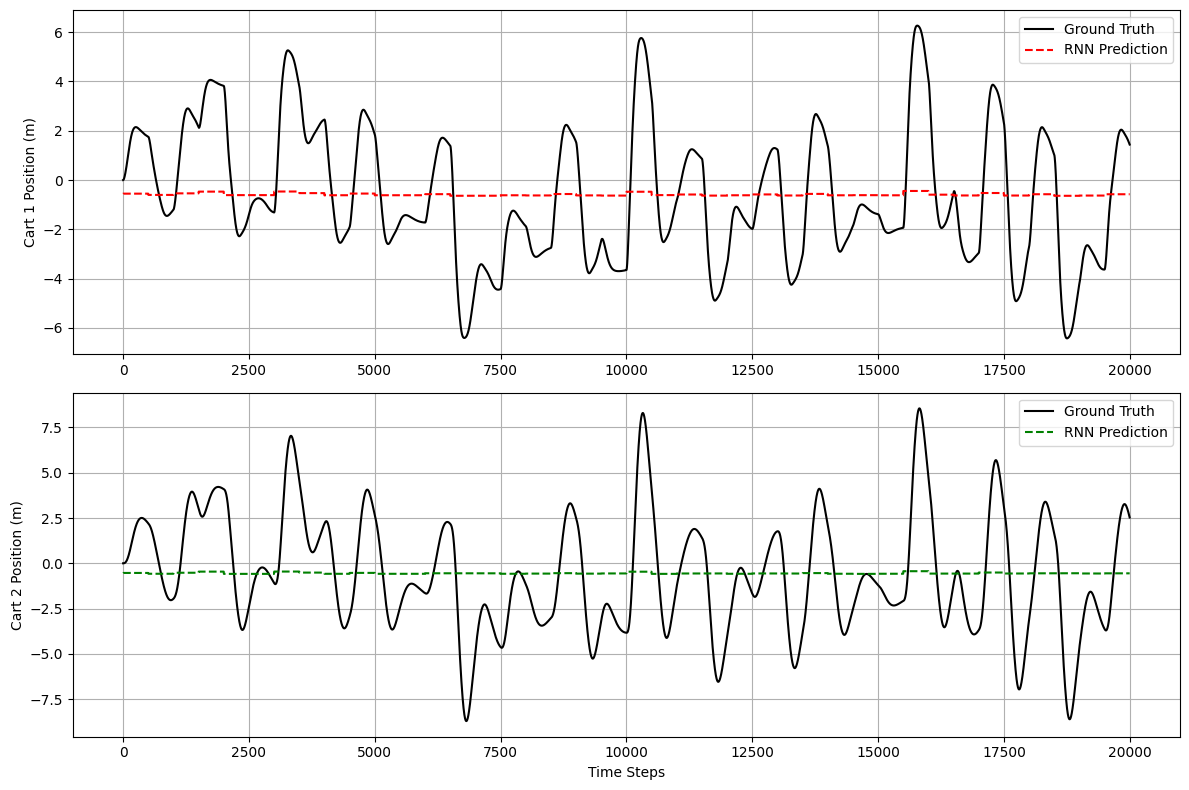

In [43]:
# train the model
print("Evaluating trained RNN for size 4 ")
with torch.no_grad():
    # Pass the ENTIRE sequence U through the model
    device = next(model.parameters()).to(device)
    Y_pred_norm = model(U.to(device))
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * y_std + y_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Cart 1 Position (x1)
plt.subplot(2, 1, 1)
plt.plot(y_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Cart 1 Position (m)')
plt.legend()
plt.grid(True)

# Plot Cart 2 Position (x2)
plt.subplot(2, 1, 2)
plt.plot(y_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Cart 2 Position (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Training with `hidden_size=64` and `seq_len=100`. Also lowered learning rate to 0.0001 and applied gradient clipping

In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# train the model
model = RNN(input_size=1, hidden_size=64, output_size=4).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# training loop
n_epochs = 100
seq_len = 100

loss_history = []

batch_size = 16

for epoch in range(n_epochs):
    # zero the gradients
    optimizer.zero_grad()
    
    batch_loss = 0

    for _ in range(batch_size):
        # Pick a random starting point in the sequence
        start_idx = np.random.randint(0, len(U) - seq_len)
        end_idx = start_idx + seq_len
        
        # Get the chunks of data using slicing [start_idx:end_idx]
        U_chunk = U[start_idx:end_idx].to(device)
        Y_chunk = Y[start_idx:end_idx].to(device)
        
        # Forward pass
        Y_pred_chunk = model(U_chunk)
        
        # Calculate Loss
        loss = criterion(Y_pred_chunk, Y_chunk)
        
        # Backpropagate and Update
        loss.backward()

        batch_loss += loss.item()
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    loss_history.append(loss.item())
    
    # Print the loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Average Batch Loss: {batch_loss / batch_size:.4f}")

Training on: cuda
Epoch 10/100, Average Batch Loss: 1.3392
Epoch 20/100, Average Batch Loss: 1.0899
Epoch 30/100, Average Batch Loss: 0.9274
Epoch 40/100, Average Batch Loss: 0.9755
Epoch 50/100, Average Batch Loss: 1.0393
Epoch 60/100, Average Batch Loss: 0.9830
Epoch 70/100, Average Batch Loss: 1.1602
Epoch 80/100, Average Batch Loss: 0.7979
Epoch 90/100, Average Batch Loss: 0.8926
Epoch 100/100, Average Batch Loss: 1.2694


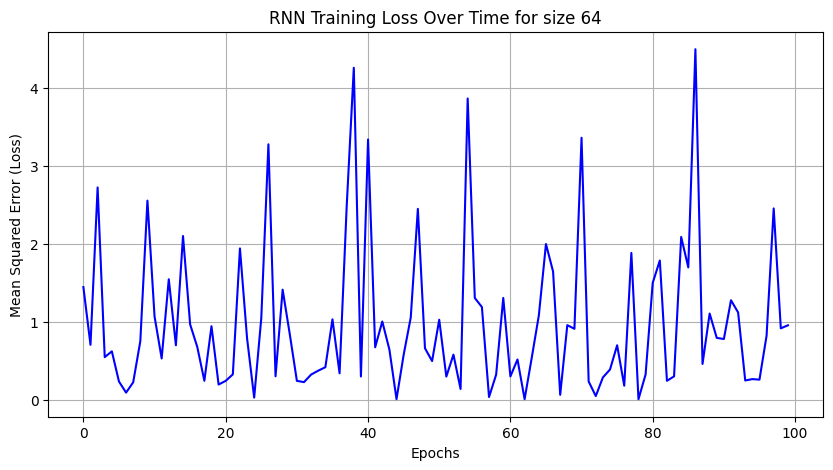

In [45]:
# Plot the Learning Curve
plt.figure(figsize=(10, 5))

# Plot the saved list
plt.plot(loss_history, color='blue')
plt.title('RNN Training Loss Over Time for size 64')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.grid(True)
plt.show()


Evaluating trained RNN for size 64


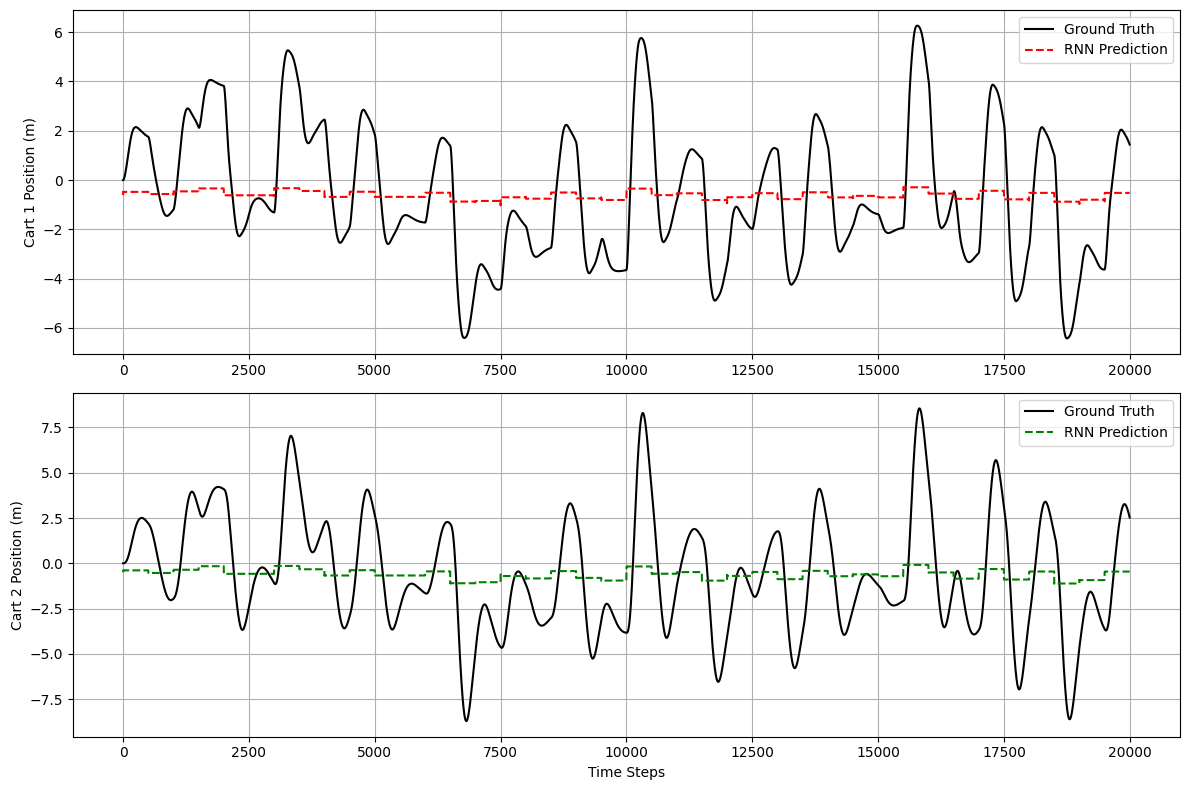

In [46]:
# train the model
print("Evaluating trained RNN for size 64")
with torch.no_grad():
    # Pass the ENTIRE sequence U through the model
    device = next(model.parameters()).to(device)
    Y_pred_norm = model(U.to(device))
    # Convert to numpy and un-normalize
    Y_pred = Y_pred_norm.cpu().numpy() * y_std + y_mean

# Plotting Results
plt.figure(figsize=(12, 8))

# Plot Cart 1 Position (x1)
plt.subplot(2, 1, 1)
plt.plot(y_vals[:, 0], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 0], 'r--', label='RNN Prediction')
plt.ylabel('Cart 1 Position (m)')
plt.legend()
plt.grid(True)

# Plot Cart 2 Position (x2)
plt.subplot(2, 1, 2)
plt.plot(y_vals[:, 2], 'k-', label='Ground Truth')
plt.plot(Y_pred[:, 2], 'g--', label='RNN Prediction')
plt.ylabel('Cart 2 Position (m)')
plt.xlabel('Time Steps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()